### Model Evaluation
This notebook evaluates the performance of both the behavioral model (synthetic) and the emotion model (GoEmotions). The evaluation focuses on classification accuracy, prediction consistency, and model behavior under different data conditions.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import numpy as np
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from core.simulation_engine import simulate_behavior, behavioral_interpretation
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
print("="*50)
print("SYNTHETIC MODEL EVALUATION")
print("="*50)

SYNTHETIC MODEL EVALUATION


In [3]:
synthetic_model = joblib.load("../models/synthetic_model.pkl")
X_syn = np.load("../data/synthetic_features_scaled.npy")
y_syn = np.load("../data/synthetic_labels_final.npy", allow_pickle = True)
print(X_syn.shape, y_syn.shape)

(3274, 36) (3274,)


In [4]:
y_pred = synthetic_model.predict(X_syn)
print("Accuracy:", accuracy_score(y_syn, y_pred))
print("\nClassification Report:")
print(classification_report(y_syn, y_pred, zero_division = 0))

Accuracy: 0.9309712889431888

Classification Report:
              precision    recall  f1-score   support

  analytical       0.88      0.72      0.79       167
    avoidant       0.95      0.95      0.95      1012
    cautious       0.94      0.97      0.96      1453
   impulsive       0.90      0.92      0.91       569
   proactive       0.72      0.47      0.57        73

    accuracy                           0.93      3274
   macro avg       0.88      0.80      0.83      3274
weighted avg       0.93      0.93      0.93      3274



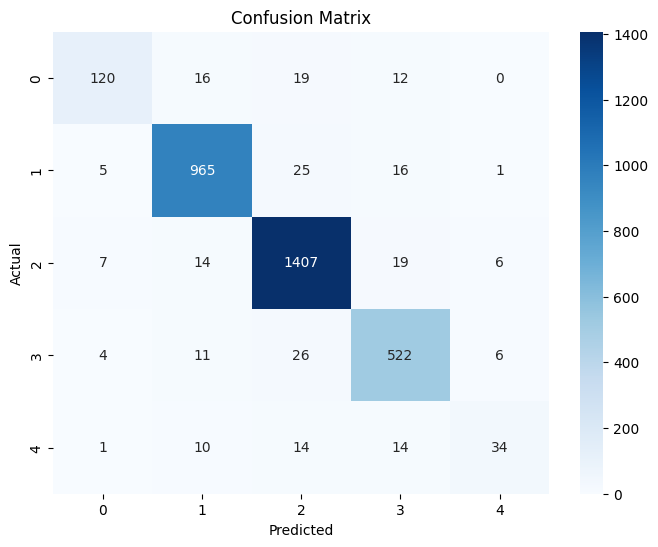

In [5]:
cm = confusion_matrix(y_syn, y_pred)
plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [6]:
test_cases = [
    { 
        "text" : "I have a new job opportunity but I feel nervous and unsure",
        "scenario" : "career",
        "difficulty" : "high"
    },

     
    { 
        "text" : "I got a promotion and I feel confident about handling it",
        "scenario" : "career",
        "difficulty" : "medium"
    },

    
    { 
        "text" : "I am facing financial issues and I feel stressed about money",
        "scenario" : "money",
        "difficulty" : "high"
    },

    
    { 
        "text" : "I had an argument with my friend and I feel confused and upset",
        "scenario" : "relationship",
        "difficulty" : "medium"
    },
    

    { 
        "text" : "I am worried about my health and I feel anxious about it",
        "scenario" : "health",
        "difficulty" : "high"
    },
    

    { 
        "text" : "I need to make a risky decision but I feel unsure and hesistant",
        "scenario" : "risk",
        "difficulty" : "high" 
    }]
results = []
for case in test_cases:
    result = simulate_behavior(user_text = case["text"], scenario = case["scenario"], difficulty = case["difficulty"])
    results.append({"Input" : case["text"],
                    "Scenario" : case["scenario"],
                    "Difficulty" : case["difficulty"],
                    "Detected Emotion" : result["Detected Emotion"],
                    "Mapped State" : result["Mapped Emotion"],
                    "Decision" : result["Predicted Decision"]
                   })
pd.DataFrame(results)

,Input,Scenario,Difficulty,Detected Emotion,Mapped State,Decision
0,I have a new job opportunity but I feel nervous and unsure,career,high,nervousness,anxious,avoidant
1,I got a promotion and I feel confident about handling it,career,medium,approval,thinking,cautious
2,I am facing financial issues and I feel stressed about money,money,high,nervousness,anxious,avoidant
3,I had an argument with my friend and I feel confused and upset,relationship,medium,confusion,thinking,cautious
4,I am worried about my health and I feel anxious about it,health,high,nervousness,anxious,avoidant
5,I need to make a risky decision but I feel unsure and hesistant,risk,high,nervousness,anxious,avoidant


In [7]:
result = simulate_behavior(user_text = "I have a new job opportunity but I feel nervous and unsure", scenario = "career", difficulty = "high")
result["Behavioral Interpretation"] = behavioral_interpretation(result["Mapped Emotion"], "high", result["Predicted Decision"])
print("Case Study Result:\n")
print(f"Predicted Decision : {result['Predicted Decision']}")
print(f"Confidence Level   : {result['Confidence']}")
print(f"Detected Emotion   : {result['Detected Emotion']}")
print(f"Mapped Emotion     : {result['Mapped Emotion']}")
print("\nExplanation:\n")
print(result["Explanation"])
print("\nBehavioral Interpretation:\n")
print(result["Behavioral Interpretation"])

Case Study Result:

Predicted Decision : avoidant
Confidence Level   : 1.0
Detected Emotion   : nervousness
Mapped Emotion     : anxious

Explanation:

The dominant detected emotion is 'nervousness', Which maps to the behavioral state 'anxious'.
For the selected scenario 'career' with difficulty level 'high', the predicted decision tendency is 'avoidant'.

Behavioral Interpretation:

Feeling anxious in challenging situations can increase the tendency to avoid decisions.Higher difficulty levels can increase emotional pressure and effect decision patterns.Using structured planning and breaking the problem into smaller steps may help reduce avoidance.


### Synthetic Model Analysis
The synthetic model achieves high accuracy due to the structured and controlled dataset. The predefined relationships between features allow the model to learn clear decision patterns effectively.

The confusion matrix shows strong diagonal dominance, indicating that most predictions are correct with minimal misclassification. 

In [8]:
print("="*50)
print("GOEMOTIONS MODEL EVALUATION")
print("="*50)

GOEMOTIONS MODEL EVALUATION


In [9]:
go_model = joblib.load("../models/goemotions_model.pkl")
X_go = joblib.load("../data/goemotions_tfidf_features.pkl")
y_go = np.load("../data/goemotions_labels.npy")
y_pred_go = go_model.predict(X_go)
print("Accuracy:", accuracy_score(y_go, y_pred_go))
print("\nClassification Report:")
print(classification_report(y_go, y_pred_go, zero_division = 0))

Accuracy: 0.03310796179110224

Classification Report:
              precision    recall  f1-score   support

           0       0.37      0.84      0.51     17131
           1       0.41      0.89      0.56      9245
           2       0.21      0.86      0.33      8084
           3       0.19      0.78      0.31     13618
           4       0.20      0.72      0.31     17620
           5       0.15      0.88      0.26      5999
           6       0.15      0.81      0.25      7359
           7       0.16      0.79      0.27      9692
           8       0.15      0.89      0.26      3817
           9       0.14      0.81      0.24      8469
          10       0.17      0.79      0.27     11424
          11       0.16      0.89      0.27      5301
          12       0.11      0.88      0.19      2476
          13       0.14      0.86      0.24      5629
          14       0.20      0.92      0.33      3197
          15       0.57      0.91      0.70     11625
          16       0.10    

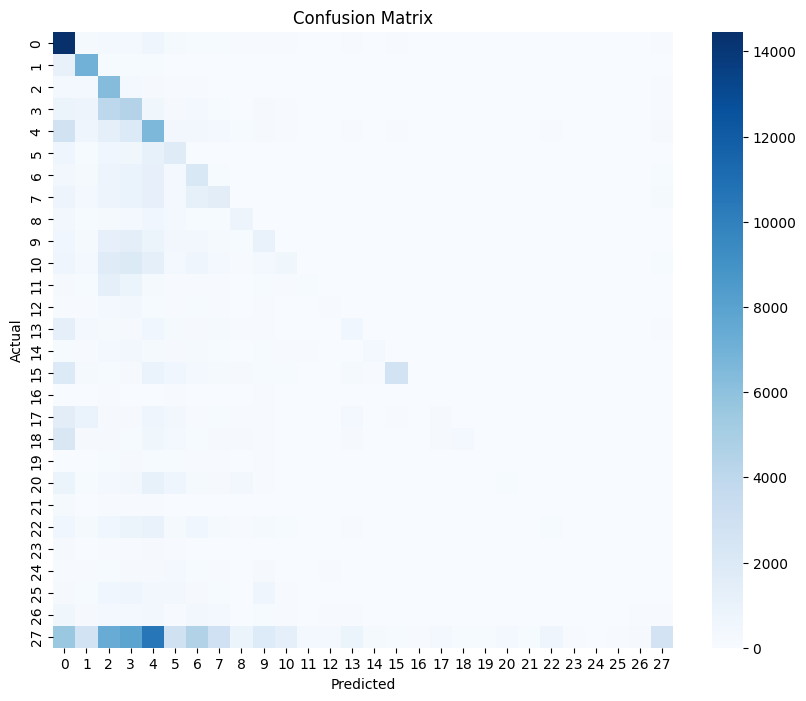

In [10]:
y_go_single = np.argmax(y_go, axis = 1)
y_pred_go = np.argmax(y_pred_go, axis = 1)
cm_go = confusion_matrix(y_go_single, y_pred_go)
plt.figure(figsize = (10, 8))
sns.heatmap(cm_go,cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### GoEmotions Model Analysis
The GoEmotions model shows lower accuracy due to the complexity and imbalance of real-world emotional data. Overlapping emotional categories and noise in text make classification challenging.

Despite this, the model captures dominant emotional signals effectively, demonstrating its ability to handle real-world variability.